In [59]:
#all dependencies 
%pip install scikit-learn pandas numpy matplotlib pvmismatch pvlib numpy
%load_ext autoreload
%autoreload 2

#import the python files needed
import cell_ann
from refactored_single_cell import Cell
import refactored_prediction
import refactored_whole_module
import DPSO_MPPT

Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


# Demo
## Predicting Parameters
The first step is to predict the parameters for a single cell. Parameters include $I_{ph}$, $I_o$, $R_s$, $R_{sh}$, and $a$ This is originally done with a least square method and heuristics. This requires datasheet variables including the Voc, Isc, Pmp and temperature coefficients. 

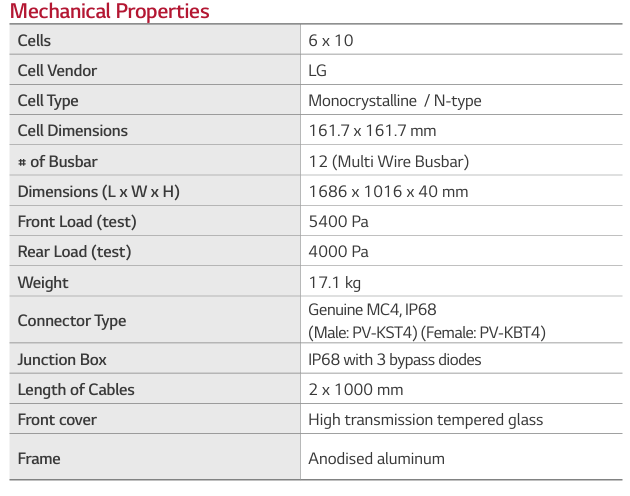

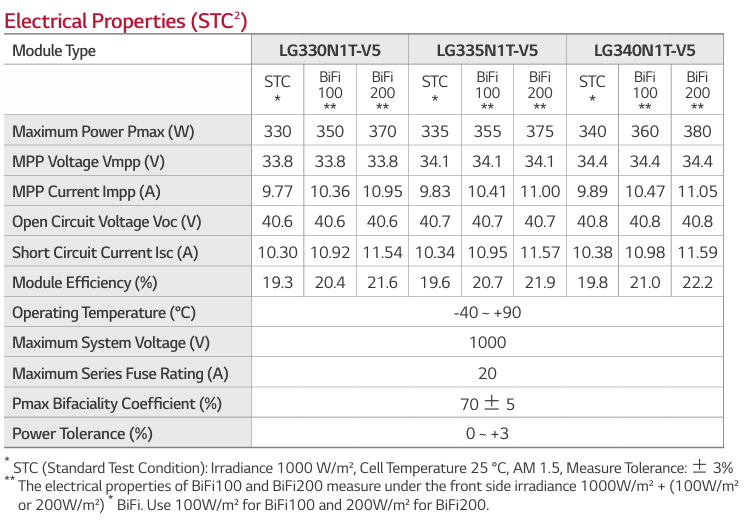

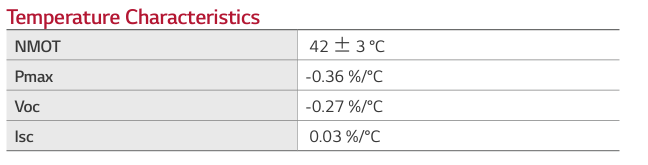

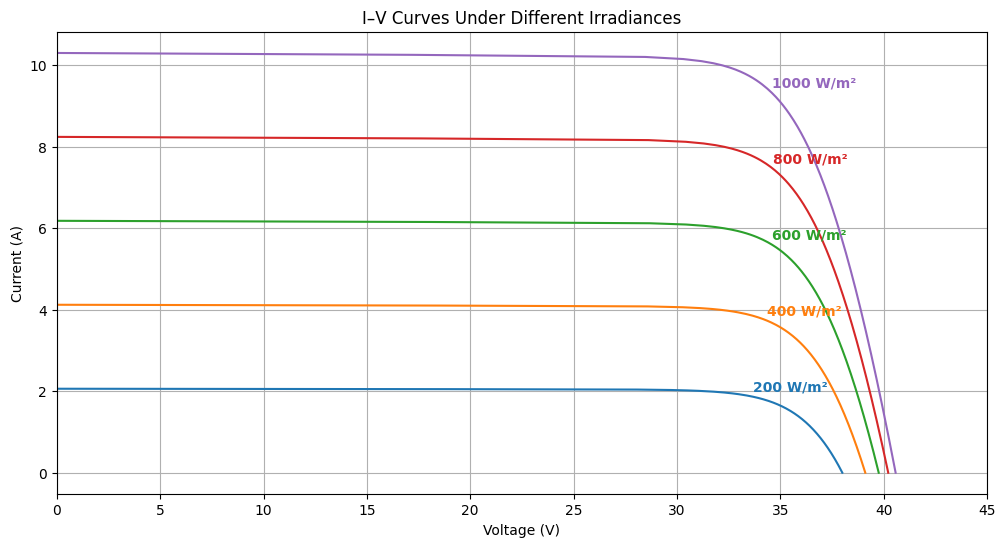

In [3]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

def get_curve(a, iph, isat, rs, rsh, specs):
    max_v = 0
    voltages = []
    current_targets = np.linspace(0, iph, 200)
    v_guess = specs['V_oc'] * 0.99
    for I in current_targets:
        sol = fsolve(iv_equation, v_guess, args=(I, a, iph, isat, rs, rsh,))[0]
        voltages.append(sol)
        v_guess = sol
    return voltages, current_targets

def iv_equation(V, I, a, iph, isat, rs, rsh):
    exponent = (V + I * rs)/(a)
    exponent_term = isat * (np.exp(np.clip(exponent, -50, 50)) -1)
    rsh_term = (V + I * rs)/rsh
    return (iph - exponent_term - rsh_term - I)

#specs from the LG330N1T-V5 panel datasheet
specs = {
    'tech': 'mono-c-si',
    'N_s': 60,
    'I_sc': 10.3,        
    'V_oc': 40.6,
    'I_mp': 9.77,
    'V_mp': 33.8,
    'alpha_sc': 0.03,
    'beta_oc': -0.27,
    'gamma': -0.36
}

#returned params and curve list for next section
param_list = []
curves = []

plt.figure(figsize=(12, 6))

#iterate from 200 to 1000 
for i in range(5):
    irr = (i+1)*200

    #calc params
    params = refactored_prediction.param_solver(specs, 25, irr)
    param_list.append(params)
    a_ref, iph_ref, isat_ref, rs, rsh = params

    #calculate iv curve and show graph
    V, I = get_curve(a_ref, iph_ref, isat_ref, rs, rsh, specs)
    curves.append((V, I))

    line = plt.plot(V, I)
    plt.text(V[-20], I[-20] + 0.15, f"{irr} W/m²", color=line[0].get_color(), fontweight='bold')

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("I–V Curves Under Different Irradiances")
plt.xlim(0, 45)
plt.grid(True)


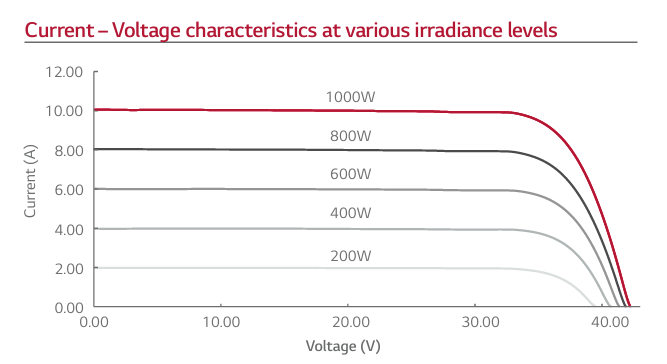

## Cell Conversion
This is for the whole panel. We want to calculate for each individual cell. Current stays constant, but different voltages, resistances and diode ideality. Voltages and ideality can be solved by dividing by number of cells, but resistances need to be found to fit the curve. 60 cells, therefore resulting curves should be voltages of /60 (40/60 = 2/3 = 0.67).

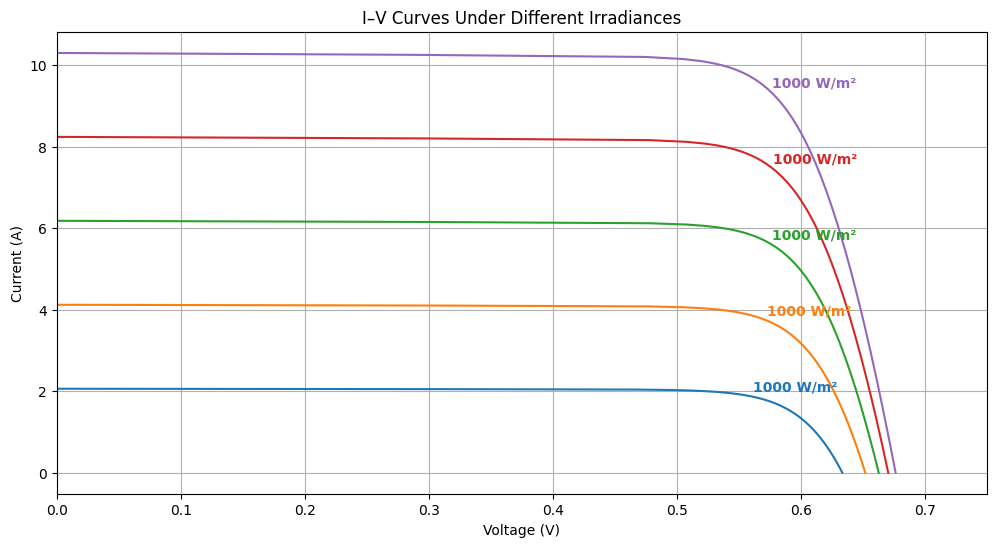

In [4]:
from scipy.optimize import least_squares

def cell_params(V, I, a, iph, isat, rs, rsh, specs):
    points = [(V/specs['N_s'], I) for (V, I) in zip(V,I)]
    a = a / specs['N_s']
    def residuals(x):
        Rs, Rsh = x
        res = []
        for V, I in points:
            I_calc = iph - isat*(np.exp(np.clip((V + I*Rs)/(a), -50, 50)) - 1) - (V + I*Rs)/Rsh
            res.append(I_calc - I)
        return res
    x0 = [rs/specs['N_s'], rsh/specs['N_s']]
    sol = least_squares(residuals, x0, bounds=([0.001, 1],[75, 1e6]),)
    rs, rsh = sol.x
    return a, iph, isat, rs, rsh

plt.figure(figsize=(12, 6))

#adjust parameters for single cell then return 
for i, curve in enumerate(curves):
    V, I = curve
    a, iph, isat, rs, rsh = param_list[i]
    a, iph, isat, rs, rsh = cell_params(V, I, a, iph, isat, rs, rsh, specs)

    #regenerate curves
    V, I = get_curve(a, iph, isat, rs, rsh, specs)

    line = plt.plot(V, I)
    plt.text(V[-20], I[-20] + 0.15, f"{irr} W/m²", color=line[0].get_color(), fontweight='bold')

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("I–V Curves Under Different Irradiances")
plt.xlim(0, 0.75)
plt.grid(True)




## Cell ANN
Uses the refactored_single_cell.py file to generate a class wide neural network based on data in the training data folder. This contains a series of temperatures and irradiances, and their equivalent 5 parameter model. Cell class also allows setting of temperature/shade to recalculate later. Should match the above graph but faster

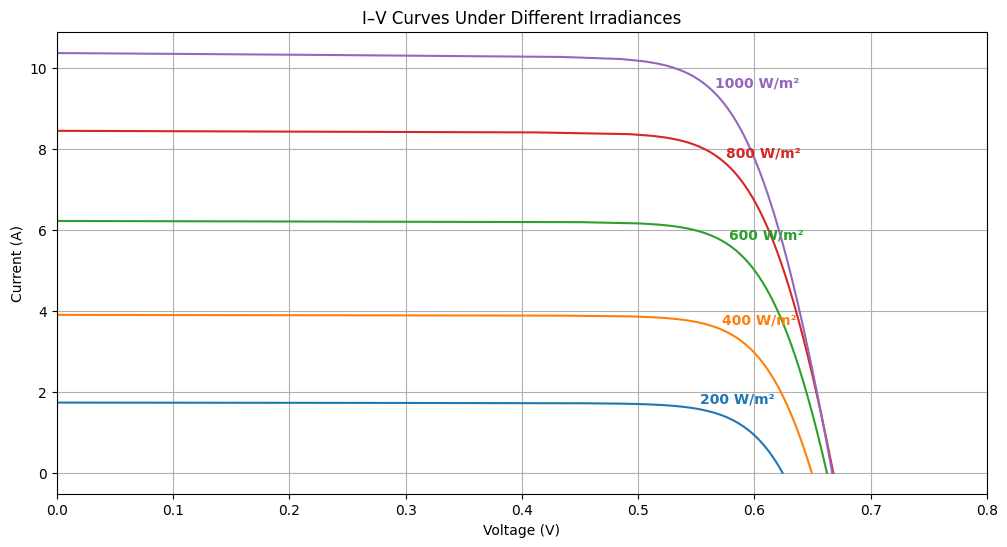

In [12]:
#redo the above single cell calculations with the cell class - uses ANN
plt.figure(figsize=(12, 6))

for i in range(5):
    irr = (i+1)*200

    #generate cells and calc curve
    temp_cell = Cell(irr, 25, "LG_Electronics_Inc__LG330N1T_V5", specs)
    a, iph, isat, rs, rsh = temp_cell.get_params()

    #regenerate curvesPrism_Solar_Technologies_Bi48_267BSTC_pv
    V, I = get_curve(a, iph, isat, rs, rsh, specs)

    line = plt.plot(V, I)
    plt.text(V[-20], I[-20] + 0.15, f"{irr} W/m²", color=line[0].get_color(), fontweight='bold')

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("I–V Curves Under Different Irradiances")
plt.xlim(0, 0.8)
plt.grid(True)


## Whole Module 
Iterate over a series of voltages for the whole panel, solve the residuals for each voltage, and use to calculate voltage power curve. This can be compared against the paper graphs. Testing with a 60 cell module though instead of 48.

Running Test 1: Unshaded (STC)
Running Test 2: One Substring Shaded
Running Test 3: Two Substrings Lightly Shaded
Running Test 4: Two Substrings Heavily shaded
Comparison Complete


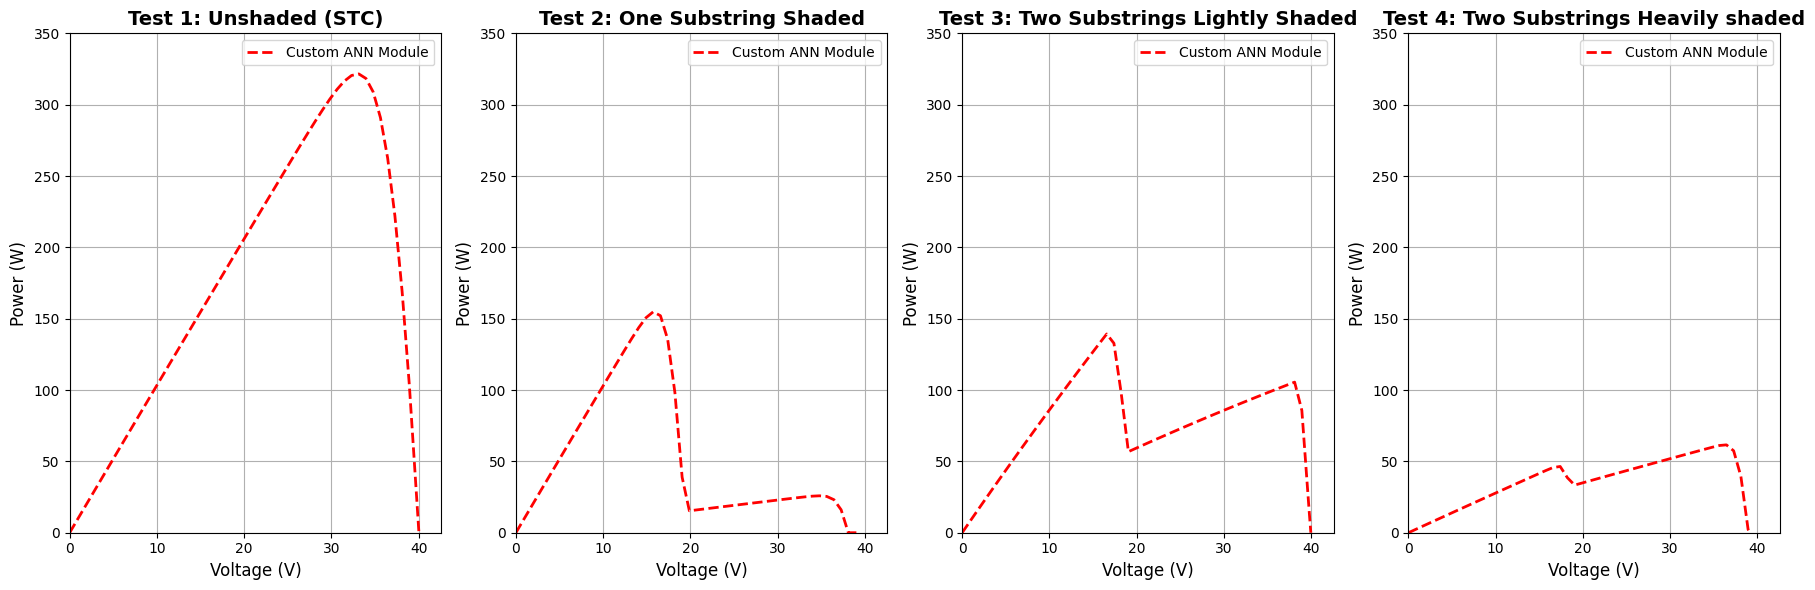

In [ ]:


#generating our module
module = refactored_whole_module.Module("LG_Electronics_Inc__LG330N1T_V5", specs)
module.d = 2

#3 test cases
#case 1 unshaded
irr_case_1 = [1000.0] * 60

#case 2 1 substring shaded in substring 1
irr_case_2 = [1000.0] * 60
irr_case_2[0:29] = [100.0] * 29

#case 3 heavy shade in substring 1 and moderate in substring 2
irr_case_3 = [1000.0] * 60
irr_case_3[0:3] = [300.0] * 3
irr_case_3[31:34] = [800.0] * 3

irr_case_4 = [1000.0] * 60
irr_case_4[0:15] = [200.0] * 15
irr_case_4[31:45] = [300.0] * 14

test_cases = [irr_case_1, irr_case_2, irr_case_3, irr_case_4]
titles = ["Test 1: Unshaded (STC)", "Test 2: One Substring Shaded", "Test 3: Two Substrings Lightly Shaded", "Test 4: Two Substrings Heavily shaded"]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, ax in enumerate(axes):
    print(f'Running {titles[i]}')
    current_irr = test_cases[i]

    #custom solver
    module.set_cell_conditions(irr_array=current_irr)
    V_cust, P_cust = module.calculate_iv()

    ax.plot(V_cust, P_cust, label='Custom ANN Module', color='red', linestyle='--', linewidth=2)
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.set_xlabel("Voltage (V)", fontsize=12)
    ax.set_ylabel("Power (W)", fontsize=12)
    ax.set_xlim(0, module.voc + 2)
    ax.set_ylim(0, 350)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
print("Comparison Complete")


# Maximum Power Point Tracking
This tends to be slow - so use a max power point tracking method (DPSO) to find the best power. Switches between local and global - global still slowish but local fast. Due to bypass diode should be minimal change between first and second. 3rd shades the last substring - should see a change.

Converged on power after 8 iterations.
Tracker pmp is 94.99672664284687 and actual is 95.6655658704641
Difference between tracker and actual is 0.6688392276172408
Tracker pmp is 94.75658481040026 and actual is 95.61236941286855
Difference between tracker and actual is 0.8557846024682902


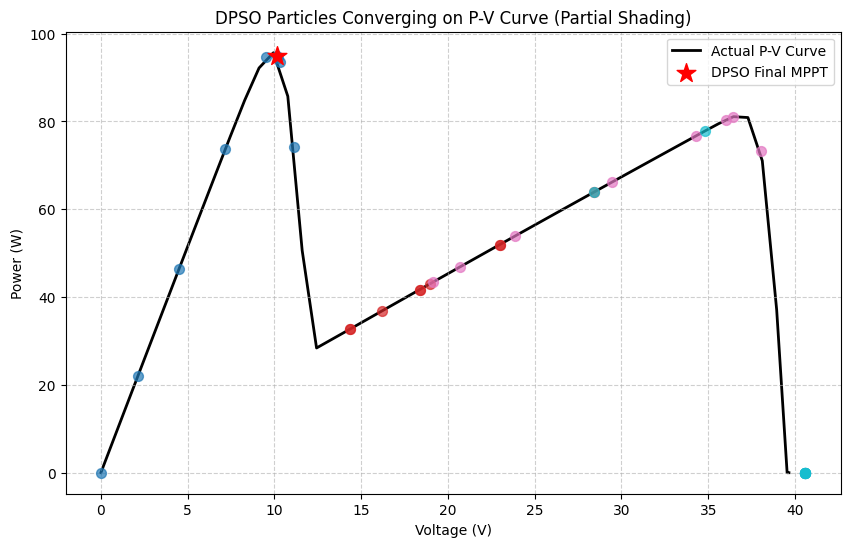

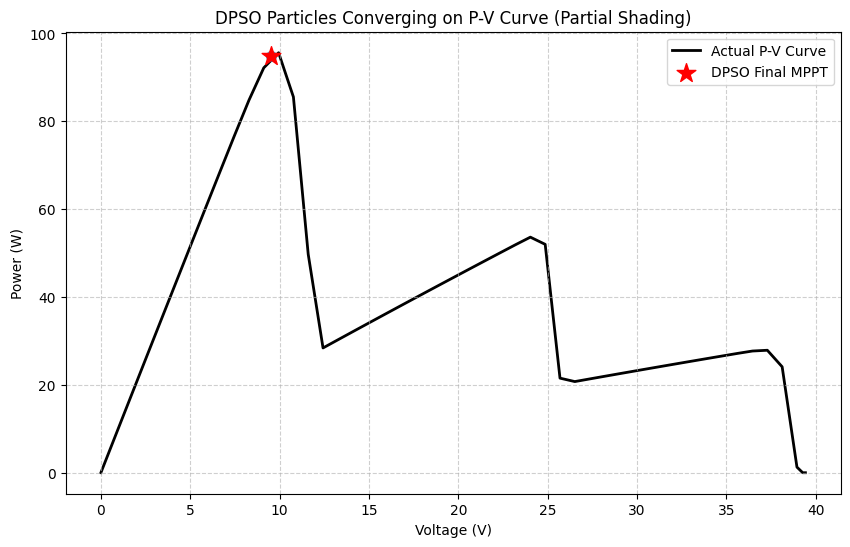

In [ ]:
import matplotlib.cm as cm
module.d = 3
#the dpso takes in a min/max load, the module and the number of particles used to track
tracker = DPSO_MPPT.DPSO_MPPT(num_particles=4, module=module, RL_min=0, RL_max=module.voc)

#irr array - want to show 2 peaks
irr_array = [1000.0] * 60
irr_array[6:14] = [250] * 8
irr_array[43:50] = [250] * 7

#calculate using the tracker & the full graph
print("Starting tracker")
tracker.set_module_conditions(irr_array=irr_array)
tracker_vmp, tracker_pmp, history = tracker.track_mpp()
tracker.state = 'Local'
print("Starting curve")
V, P = module.calculate_iv()
module_pmp = P[np.argmax(P)]

print(f'Tracker pmp is {tracker_pmp} and actual is {module_pmp}')
print(f'Difference between tracker and actual is {np.abs(tracker_pmp - module_pmp)}')

plt.figure(figsize=(10, 6))
plt.plot(V, P, label='Actual P-V Curve', color='black', linewidth=2, zorder=1)
g_num_particles = len(history[0]['voltages'])
colors = cm.tab10(np.linspace(0, 1, g_num_particles))
for p_idx in range(g_num_particles):
    p_voltages = [step['voltages'][p_idx] for step in history]
    p_powers = [step['powers'][p_idx] for step in history]
    plt.scatter(p_voltages, p_powers, color=colors[p_idx], s=50, alpha=0.7, zorder=2)

plt.scatter(tracker_vmp, tracker_pmp, color='red', marker='*', s=200, label='DPSO Final MPPT', zorder=3)

plt.title('DPSO Particles Converging on P-V Curve (Partial Shading)')
plt.xlabel('Voltage (V)')
plt.ylabel('Power (W)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

#update slightly in local mode
irr_array[6:18] = [100] * 12
print("Starting tracker")
tracker.set_module_conditions(irr_array=irr_array)
tracker_vmp, tracker_pmp, history = tracker.track_mpp()
print("Starting curve")
V, P = module.calculate_iv()
module_pmp = P[np.argmax(P)]

print(f'Tracker pmp is {tracker_pmp} and actual is {module_pmp}')
print(f'Difference between tracker and actual is {np.abs(tracker_pmp - module_pmp)}')

plt.figure(figsize=(10, 6))
plt.plot(V, P, label='Actual P-V Curve', color='black', linewidth=2, zorder=1)
g_num_particles = len(history[0]['voltages'])
colors = cm.tab10(np.linspace(0, 1, g_num_particles))
for p_idx in range(g_num_particles):
    p_voltages = [step['voltages'][p_idx] for step in history]
    p_powers = [step['powers'][p_idx] for step in history]
    plt.scatter(p_voltages, p_powers, color=colors[p_idx], s=50, alpha=0.7, zorder=2)

plt.scatter(tracker_vmp, tracker_pmp, color='red', marker='*', s=200, label='DPSO Final MPPT', zorder=3)

plt.title('DPSO Particles Converging on P-V Curve (Partial Shading)')
plt.xlabel('Voltage (V)')
plt.ylabel('Power (W)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

#update - should change to global mode
irr_array[22:34] = [300] * 12
print("Starting tracker")
tracker.set_module_conditions(irr_array=irr_array)
tracker_vmp, tracker_pmp, history = tracker.track_mpp()
print("Starting curve")
V, P = module.calculate_iv()
module_pmp = P[np.argmax(P)]

print(f'Tracker pmp is {tracker_pmp} and actual is {module_pmp}')
print(f'Difference between tracker and actual is {np.abs(tracker_pmp - module_pmp)}')

plt.figure(figsize=(10, 6))
plt.plot(V, P, label='Actual P-V Curve', color='black', linewidth=2, zorder=1)
g_num_particles = len(history[0]['voltages'])
colors = cm.tab10(np.linspace(0, 1, g_num_particles))
for p_idx in range(g_num_particles):
    p_voltages = [step['voltages'][p_idx] for step in history]
    p_powers = [step['powers'][p_idx] for step in history]
    plt.scatter(p_voltages, p_powers, color=colors[p_idx], s=50, alpha=0.7, zorder=2)

plt.scatter(tracker_vmp, tracker_pmp, color='red', marker='*', s=200, label='DPSO Final MPPT', zorder=3)

plt.title('DPSO Particles Converging on P-V Curve (Partial Shading)')
plt.xlabel('Voltage (V)')
plt.ylabel('Power (W)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
